In [1]:
import os
import glob
import random
import json
import math
import gc

import h5py
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 配置

In [2]:
class CFG:
    OBS_PATTERNS = [
        "./data_HI/sim_mock*/NonImaging_Patch_gaussian_surveysim-beam_*.h5",
    ]

    INPUT_KEY = "Observed_Patch"
    TARGET_KEY = "HI_Patch_conv"

    FREQ_KEY = "Frequency_MHz"
    DEC_KEY = "Dec_deg"
    RA_KEY = "RA_deg"

    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    TRAIN_RATIO = 0.75
    VAL_RATIO = 0.15
    TEST_RATIO = 0.10

    # 为了和 PCA+U2Net 尽量公平，这里也采用 patch batch 训练
    BATCH_SIZE = 128
    NUM_WORKERS = 0

    EPOCHS = 160
    LR = 1e-4
    WEIGHT_DECAY = 5e-5

    USE_AMP = True if torch.cuda.is_available() else False
    EPS = 1e-6
    CLIP_SIGMA = 5.0
    MAX_GRAD_NORM = 1.0
    EARLY_STOP_PATIENCE = 20

    # PCA
    PCA_NCOMP = 4
    PCA_SOFT_F = True

    # patch training
    PATCH_F = 80
    PATCH_H = 48
    PATCH_W = 49

    TRAIN_PATCHES_PER_FILE = 16
    VAL_PATCHES_PER_FILE = 6
    TEST_PATCHES_PER_FILE = 6

    # weighted sliding inference
    INFER_STRIDE_F = 40
    INFER_STRIDE_H = 24
    INFER_STRIDE_W = 49

    BLEND_MIN_WEIGHT = 0.05
    DISPLAY_INTERP = "bicubic"

    # 和 PCA+U2Net 复用同一个 split，保证公平比较
    REUSE_SPLIT_PATH = "./pca_u2net_original_final/data_split.json"
    REUSE_STATS_PATH = None
    USE_CACHE = True

    # UNet backbone
    BASE_CHANNELS = 8
    DEEP_SUPERVISION = True

    SAVE_DIR = "./pca_unet_final"
    BEST_BY_LOSS_NAME = "best_pca_unet_by_loss.pth"
    BEST_BY_CORR_NAME = "best_pca_unet_by_corr.pth"
    LAST_MODEL_NAME = "last_pca_unet_model.pth"
    STATS_NAME = "norm_stats_pca.json"
    SPLIT_NAME = "data_split.json"

    FIG_SAVE_DIR = "./unet"

os.makedirs(CFG.SAVE_DIR, exist_ok=True)
os.makedirs(CFG.FIG_SAVE_DIR, exist_ok=True)

print("Device:", CFG.DEVICE)
print("Save dir:", CFG.SAVE_DIR)
print("Figure save dir:", CFG.FIG_SAVE_DIR)

Device: cuda
Save dir: ./pca_unet_final
Figure save dir: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/unet成果图


# 基础函数

In [3]:
# 基础工具函数
def seed_everything(seed=42):
    """固定随机种子，确保实验可复现"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.SEED)


def cleanup_cuda():
    """清理 GPU 缓存，释放显存"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def collect_files(patterns):
    """根据通配符收集所有文件路径，去重排序"""
    files = []
    for p in patterns:
        files.extend(glob.glob(p))
    files = sorted(list(set(files)))
    return files


def split_file_list(file_list, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    """将文件列表随机划分为训练/验证/测试集，保证比例总和为1"""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
    file_list = file_list.copy()
    rng = np.random.default_rng(seed)
    rng.shuffle(file_list)
    n = len(file_list)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_files = file_list[:n_train]
    val_files = file_list[n_train:n_train + n_val]
    test_files = file_list[n_train + n_val:]
    return train_files, val_files, test_files


def save_json(obj, path):
    """将字典保存为JSON文件"""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def load_json(path):
    """从JSON文件读取字典"""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_h5_array(h5_path, key):
    """从 HDF5 文件中读取指定键的数据，返回 float32 数组"""
    with h5py.File(h5_path, "r") as f:
        arr = f[key][()]
    return np.asarray(arr, dtype=np.float32)

# 保存图片工具

In [4]:
def save_figure(fig, name_prefix, save_pdf=True, save_png=True, dpi=300):
    os.makedirs(CFG.FIG_SAVE_DIR, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    safe_prefix = str(name_prefix).replace(" ", "_").replace("/", "_")

    if save_pdf:
        pdf_path = os.path.join(CFG.FIG_SAVE_DIR, f"{safe_prefix}_{timestamp}.pdf")
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
        print("Saved PDF:", pdf_path)

    if save_png:
        png_path = os.path.join(CFG.FIG_SAVE_DIR, f"{safe_prefix}_{timestamp}.png")
        fig.savefig(png_path, format="png", dpi=dpi, bbox_inches="tight")
        print("Saved PNG:", png_path)

# pca预处理函数

In [5]:
# PCA 前景减除函数
def pca_subtraction_cube(input_cube, n_comp=3, soft_f=True):
    """
    对三维数据立方体进行 PCA 前景去除。

    参数：
        input_cube: 形状 (F, H, W) 的输入数据
        n_comp: 去除的主成分个数
        soft_f: 若为 True，在空间维度上进行 PCA（每列是一个像素的频谱）；
                若为 False，在频率维度上进行 PCA（每列是一个频率通道的空间图）
    返回：
        PCA 残差立方体，形状保持 (F, H, W)
    """
    cube = np.asarray(input_cube, dtype=np.float32)
    cube = np.nan_to_num(cube, nan=0.0, posinf=0.0, neginf=0.0)

    original_shape = cube.shape
    f_dim = original_shape[0]

    x = cube.reshape(f_dim, -1)  # (F, H*W)

    if soft_f:
        x = np.moveaxis(x, 0, -1)  # (H*W, F)

    max_comp = min(x.shape[0], x.shape[1])
    n_comp = max(1, min(n_comp, max_comp))

    pca = PCA(
        n_components=n_comp,
        svd_solver="randomized",
        random_state=CFG.SEED
    )
    x_low = pca.fit_transform(x)
    x_recon = pca.inverse_transform(x_low)
    x_clean = x - x_recon

    if soft_f:
        x_clean = np.moveaxis(x_clean, 0, -1)

    x_clean = x_clean.reshape(original_shape).astype(np.float32)
    return x_clean

# 文件列表和split

In [6]:
all_files = collect_files(CFG.OBS_PATTERNS)
print("Total files found:", len(all_files))

if len(all_files) == 0:
    raise RuntimeError("没有找到 h5 文件，请检查 CFG.OBS_PATTERNS")

print("Example file:", all_files[0])

with h5py.File(all_files[0], "r") as f:
    print("Top-level keys:", list(f.keys()))
    for k in f.keys():
        print(k, f[k].shape, f[k].dtype)

if CFG.REUSE_SPLIT_PATH is not None and os.path.exists(CFG.REUSE_SPLIT_PATH):
    split_data = load_json(CFG.REUSE_SPLIT_PATH)
    train_files = split_data["train_files"]
    val_files = split_data["val_files"]
    test_files = split_data["test_files"]
    print("\nLoaded split from:", CFG.REUSE_SPLIT_PATH)
else:
    train_files, val_files, test_files = split_file_list(
        all_files,
        train_ratio=CFG.TRAIN_RATIO,
        val_ratio=CFG.VAL_RATIO,
        test_ratio=CFG.TEST_RATIO,
        seed=CFG.SEED
    )
    print("\nCreated new split.")

print("Train:", len(train_files))
print("Val  :", len(val_files))
print("Test :", len(test_files))

save_json(
    {
        "train_files": train_files,
        "val_files": val_files,
        "test_files": test_files
    },
    os.path.join(CFG.SAVE_DIR, CFG.SPLIT_NAME)
)

Total files found: 1000
Example file: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/nonimaging_patch_gaussian_outputs00/sim_mock000/NonImaging_Patch_gaussian_surveysim-beam_0.h5
Top-level keys: ['Dec_deg', 'FG_Patch_conv', 'Foreground_Patch', 'Frequency_MHz', 'HI_Patch', 'HI_Patch_conv', 'Noise_RMS_K', 'Observed_Patch', 'RA_deg', 'ThermalNoise_Patch']
Dec_deg (151,) float64
FG_Patch_conv (250, 151, 49) float32
Foreground_Patch (250, 151, 49) float32
Frequency_MHz (250,) float64
HI_Patch (250, 151, 49) float32
HI_Patch_conv (250, 151, 49) float32
Noise_RMS_K (250,) float64
Observed_Patch (250, 151, 49) float32
RA_deg (49,) float64
ThermalNoise_Patch (250, 151, 49) float32

Loaded split from: ./pca_u2net_original_final/data_split.json
Train: 750
Val  : 150
Test : 100


# 计算pca后输入的统计量

In [7]:
def compute_stats_from_files_with_pca(file_list, input_key, target_key, n_comp):
    input_sum = 0.0
    input_sq_sum = 0.0
    input_count = 0

    target_sum = 0.0
    target_sq_sum = 0.0
    target_count = 0

    input_min = np.inf
    input_max = -np.inf
    target_min = np.inf
    target_max = -np.inf

    for fp in file_list:
        x_raw = load_h5_array(fp, input_key)
        x = pca_subtraction_cube(x_raw, n_comp=n_comp, soft_f=CFG.PCA_SOFT_F)
        y = load_h5_array(fp, target_key)

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

        input_sum += x.sum()
        input_sq_sum += (x ** 2).sum()
        input_count += x.size
        input_min = min(input_min, x.min())
        input_max = max(input_max, x.max())

        target_sum += y.sum()
        target_sq_sum += (y ** 2).sum()
        target_count += y.size
        target_min = min(target_min, y.min())
        target_max = max(target_max, y.max())

    input_mean = input_sum / input_count
    target_mean = target_sum / target_count

    input_var = input_sq_sum / input_count - input_mean ** 2
    target_var = target_sq_sum / target_count - target_mean ** 2

    input_std = math.sqrt(max(input_var, CFG.EPS))
    target_std = math.sqrt(max(target_var, CFG.EPS))

    stats = {
        "input_mean": float(input_mean),
        "input_std": float(input_std),
        "input_min": float(input_min),
        "input_max": float(input_max),
        "target_mean": float(target_mean),
        "target_std": float(target_std),
        "target_min": float(target_min),
        "target_max": float(target_max),
    }
    return stats


if CFG.REUSE_STATS_PATH is not None and os.path.exists(CFG.REUSE_STATS_PATH):
    stats = load_json(CFG.REUSE_STATS_PATH)
    print("Loaded stats from:", CFG.REUSE_STATS_PATH)
else:
    stats = compute_stats_from_files_with_pca(
        train_files,
        input_key=CFG.INPUT_KEY,
        target_key=CFG.TARGET_KEY,
        n_comp=CFG.PCA_NCOMP
    )
    print("Computed PCA-input stats from train set.")

print(stats)
save_json(stats, os.path.join(CFG.SAVE_DIR, CFG.STATS_NAME))

Computed PCA-input stats from train set.
{'input_mean': -3.743006280076801e-11, 'input_std': 0.007011841405764352, 'input_min': -0.07533657550811768, 'input_max': 0.11723363399505615, 'target_mean': 0.0001693575845453639, 'target_std': 0.015121866926134113, 'target_min': -0.06980211287736893, 'target_max': 0.513647198677063}


# 归一化与 PCA patch dataset

In [8]:
# 归一化函数
def normalize_array(arr, mean, std, clip_sigma=None):
    """标准化数组数据，可选裁剪"""
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr = (arr - mean) / (std + CFG.EPS)
    if clip_sigma is not None:
        arr = np.clip(arr, -clip_sigma, clip_sigma)
    return arr.astype(np.float32)


def denormalize_array(arr, mean, std):
    """反标准化"""
    return arr * (std + CFG.EPS) + mean


class PCAPatchDataset(Dataset):
    """
    PCA 预处理后，从完整数据立方体中随机抽取 3D 切片的 PyTorch Dataset。

    参数：
        file_list: h5 文件路径列表
        stats: 训练集统计量字典（均值、标准差等）
        input_key: 输入数据在 h5 中的键名
        target_key: 目标数据在 h5 中的键名
        n_comp: PCA 去除的主成分个数
        mode: 'train'/'val'/'test'，决定随机性及每个文件的切片数
        use_cache: 是否缓存已读取的完整立方体以加速
    """
    def __init__(self, file_list, stats, input_key="Observed_Patch", target_key="HI_Patch_conv",
                 n_comp=1, mode="train", use_cache=True):
        self.file_list = file_list
        self.stats = stats
        self.input_key = input_key
        self.target_key = target_key
        self.n_comp = n_comp
        self.mode = mode
        self.use_cache = use_cache
        self.cache = {}

        # 切片尺寸
        self.patch_f = CFG.PATCH_F
        self.patch_h = CFG.PATCH_H
        self.patch_w = CFG.PATCH_W

        # 每个文件抽取的切片数量
        if mode == "train":
            self.patches_per_file = CFG.TRAIN_PATCHES_PER_FILE
        elif mode == "val":
            self.patches_per_file = CFG.VAL_PATCHES_PER_FILE
        else:
            self.patches_per_file = CFG.TEST_PATCHES_PER_FILE

    def __len__(self):
        return len(self.file_list) * self.patches_per_file

    def _load_full_cube(self, h5_path):
        """
        加载单个 h5 文件的完整立方体，进行 PCA 和归一化处理。
        若启用缓存，则缓存结果。
        """
        if self.use_cache and h5_path in self.cache:
            return self.cache[h5_path]

        x_raw = load_h5_array(h5_path, self.input_key)
        y = load_h5_array(h5_path, self.target_key)

        # PCA 前景去除
        x_pca = pca_subtraction_cube(x_raw, n_comp=self.n_comp, soft_f=CFG.PCA_SOFT_F)

        # 归一化
        x = normalize_array(x_pca, self.stats["input_mean"], self.stats["input_std"],
                            clip_sigma=CFG.CLIP_SIGMA)
        y = normalize_array(y, self.stats["target_mean"], self.stats["target_std"],
                            clip_sigma=CFG.CLIP_SIGMA)

        x = torch.from_numpy(x).float()  # (F, H, W)
        y = torch.from_numpy(y).float()

        if self.use_cache:
            self.cache[h5_path] = (x, y)
        return x, y

    def _sample_patch(self, x, y, idx_in_file, file_idx):
        """
        从完整立方体中随机（训练）或伪随机（验证/测试）地切出一个 3D 切片。
        """
        Fdim, Hdim, Wdim = x.shape
        pf = min(self.patch_f, Fdim)
        ph = min(self.patch_h, Hdim)
        pw = min(self.patch_w, Wdim)

        if self.mode == "train":
            f0 = np.random.randint(0, max(1, Fdim - pf + 1))
            h0 = np.random.randint(0, max(1, Hdim - ph + 1))
            w0 = np.random.randint(0, max(1, Wdim - pw + 1))
        else:
            rng = np.random.default_rng(CFG.SEED + file_idx * 1000 + idx_in_file)
            f0 = int(rng.integers(0, max(1, Fdim - pf + 1)))
            h0 = int(rng.integers(0, max(1, Hdim - ph + 1)))
            w0 = int(rng.integers(0, max(1, Wdim - pw + 1)))

        x_patch = x[f0:f0+pf, h0:h0+ph, w0:w0+pw]
        y_patch = y[f0:f0+pf, h0:h0+ph, w0:w0+pw]

        # 增加通道维度 (1, F, H, W)
        return x_patch.unsqueeze(0), y_patch.unsqueeze(0), (f0, h0, w0)

    def __getitem__(self, idx):
        file_idx = idx // self.patches_per_file
        idx_in_file = idx % self.patches_per_file
        h5_path = self.file_list[file_idx]

        x, y = self._load_full_cube(h5_path)
        x_patch, y_patch, origin = self._sample_patch(x, y, idx_in_file, file_idx)
        return {"input": x_patch, "target": y_patch, "path": h5_path, "origin": origin}

# dataloader

In [9]:
train_ds = PCAPatchDataset(
    train_files, stats, CFG.INPUT_KEY, CFG.TARGET_KEY,
    n_comp=CFG.PCA_NCOMP, mode="train", use_cache=CFG.USE_CACHE
)
val_ds = PCAPatchDataset(
    val_files, stats, CFG.INPUT_KEY, CFG.TARGET_KEY,
    n_comp=CFG.PCA_NCOMP, mode="val", use_cache=CFG.USE_CACHE
)
test_ds = PCAPatchDataset(
    test_files, stats, CFG.INPUT_KEY, CFG.TARGET_KEY,
    n_comp=CFG.PCA_NCOMP, mode="test", use_cache=CFG.USE_CACHE
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

batch = next(iter(train_loader))
print("input shape :", batch["input"].shape)
print("target shape:", batch["target"].shape)
print("origin      :", batch["origin"])

input shape : torch.Size([128, 1, 80, 48, 49])
target shape: torch.Size([128, 1, 80, 48, 49])
origin      : [tensor([102,  92, 106,  20, 121,  74,  87, 103, 130,  52,  87,  37,  20,  57,
         88,  58,  14,  50,  63,  50,  20, 166, 131,  59,   8,  52,  83, 110,
          7,  34,  80,  49, 131, 133, 105,  53, 145,  43,  13,  47,  39,  81,
         23, 123, 156,  44,  88,   8, 128,  62,  80, 162,  32,  40, 134,  71,
        161,  47,  61,  36, 103,  34, 100, 130,   4, 141,  26,  14,  41,  62,
         51, 131, 150, 142,  28,  12,  70,  85,  65,  44, 133,  27,  83,  74,
        128, 120,   2, 154,  61,  50, 151,  58,  95, 112,  51,  38, 130, 112,
         80, 112, 129,  53, 128, 125,  52, 159, 159, 122,  37,  68, 138,  96,
        123,  69,  92, 147, 163,  89, 146,  95,  51, 167,  81, 128, 150,  41,
          6,  89]), tensor([ 51,  14,  71, 102,  82,  74,  99,  23,  21,   1,  29,   1,  32,  21,
         48,  41,  61,  54,   2,   6,  72,  17,  88,  13,  89,   1,  91,  59,
         46, 

# unet基础模块

In [10]:
def make_gn(num_channels):
    if num_channels % 8 == 0:
        groups = 8
    elif num_channels % 4 == 0:
        groups = 4
    else:
        groups = 1
    return nn.GroupNorm(groups, num_channels)


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, p_drop=0.05):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            make_gn(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout3d(p=p_drop),

            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            make_gn(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2, ceil_mode=True)
        self.conv = DoubleConv3D(in_ch, out_ch)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        return x


class Up3D(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv3D(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(
            x,
            size=skip.shape[2:],
            mode="trilinear",
            align_corners=False
        )
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

# pca+unet3d主体

In [11]:
class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=8, deep_supervision=True):
        super().__init__()
        self.deep_supervision = deep_supervision

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8

        self.inc = DoubleConv3D(in_channels, c1)
        self.down1 = Down3D(c1, c2)
        self.down2 = Down3D(c2, c3)
        self.down3 = Down3D(c3, c4)

        self.up1 = Up3D(c4, c3, c3)
        self.up2 = Up3D(c3, c2, c2)
        self.up3 = Up3D(c2, c1, c1)

        self.outc = nn.Conv3d(c1, out_channels, kernel_size=1)

        self.side1 = nn.Conv3d(c1, out_channels, kernel_size=1)
        self.side2 = nn.Conv3d(c2, out_channels, kernel_size=1)
        self.side3 = nn.Conv3d(c3, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        u1 = self.up1(x4, x3)
        u2 = self.up2(u1, x2)
        u3 = self.up3(u2, x1)

        d0 = self.outc(u3)

        if not self.deep_supervision:
            return d0

        d1 = self.side1(u3)
        d2 = F.interpolate(self.side2(u2), size=d0.shape[2:], mode="trilinear", align_corners=False)
        d3 = F.interpolate(self.side3(u1), size=d0.shape[2:], mode="trilinear", align_corners=False)

        return [d0, d1, d2, d3]

# 模型初始化

In [12]:
cleanup_cuda()

model = UNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=CFG.BASE_CHANNELS,
    deep_supervision=CFG.DEEP_SUPERVISION
).to(CFG.DEVICE)

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

model.eval()
with torch.no_grad():
    x = batch["input"][:1].to(CFG.DEVICE, non_blocking=True)
    with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):
        outputs = model(x)

print("input shape :", x.shape)
if isinstance(outputs, list):
    print("num outputs :", len(outputs))
    print("main output :", outputs[0].shape)
else:
    print("pred shape  :", outputs.shape)

parameters: 365,596
input shape : torch.Size([1, 1, 80, 48, 49])
num outputs : 4
main output : torch.Size([1, 1, 80, 48, 49])


# loss和metric

In [13]:
# 损失函数与评估指标
def logcosh_loss(pred, target):
    """Log-cosh 损失，对大残差不敏感，介于 L1 和 L2 之间"""
    diff = pred - target
    return torch.mean(diff + F.softplus(-2.0 * diff) - np.log(2.0))


def freq_grad_loss(pred, target):
    """频率方向的梯度损失，鼓励预测在频率维上连续"""
    pred_grad = pred[:, :, 1:, :, :] - pred[:, :, :-1, :, :]
    target_grad = target[:, :, 1:, :, :] - target[:, :, :-1, :, :]
    return F.l1_loss(pred_grad, target_grad)


def total_loss_fn(pred, target):
    """综合损失：Log-cosh 占 85%，频率梯度损失占 15%"""
    return 0.85 * logcosh_loss(pred, target) + 0.15 * freq_grad_loss(pred, target)


def compute_metrics(pred, target):
    """计算 MSE、MAE 和皮尔逊相关系数（用于监控）"""
    mse = F.mse_loss(pred, target).item()
    mae = F.l1_loss(pred, target).item()

    pred_mean = pred.mean()
    tgt_mean = target.mean()
    pred_center = pred - pred_mean
    tgt_center = target - tgt_mean

    numerator = (pred_center * tgt_center).mean()
    denominator = pred_center.std() * tgt_center.std() + 1e-8
    corr = (numerator / denominator).item()

    return {"mse": mse, "mae": mae, "corr": corr}

# 单轮训练/验证/测试

In [14]:
def run_one_epoch_pca_unet(model, loader, optimizer=None, scaler=None, device="cuda"):
    """
    运行一个 epoch 的训练或验证。
    若传入 optimizer 和 scaler 则为训练模式，否则为评估模式。
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    loss_meter = []
    mse_meter = []
    mae_meter = []
    corr_meter = []

    for batch in loader:
        x = batch["input"].to(device, non_blocking=True)
        y = batch["target"].to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):
                outputs = model(x)
                # 处理深度监督（多输出）
                if isinstance(outputs, list):
                    # 四个输出：主输出 + 三个辅助输出，权重递减
                    weights = [1.0, 0.08, 0.04, 0.02]
                    loss = sum(w * total_loss_fn(o, y) for w, o in zip(weights, outputs))
                    pred_main = outputs[0]
                else:
                    loss = total_loss_fn(outputs, y)
                    pred_main = outputs

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):
                    outputs = model(x)
                    if isinstance(outputs, list):
                        weights = [1.0, 0.08, 0.04, 0.02]
                        loss = sum(w * total_loss_fn(o, y) for w, o in zip(weights, outputs))
                        pred_main = outputs[0]
                    else:
                        loss = total_loss_fn(outputs, y)
                        pred_main = outputs

        metrics = compute_metrics(pred_main, y)

        loss_meter.append(loss.item())
        mse_meter.append(metrics["mse"])
        mae_meter.append(metrics["mae"])
        corr_meter.append(metrics["corr"])

    logs = {
        "loss": float(np.mean(loss_meter)),
        "mse": float(np.mean(mse_meter)),
        "mae": float(np.mean(mae_meter)),
        "corr": float(np.mean(corr_meter)),
    }
    return logs

# 优化器和调度器

In [15]:
optimizer = torch.optim.NAdam(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=6,
    factor=0.5,
    min_lr=5e-7
)

scaler = torch.cuda.amp.GradScaler(enabled=CFG.USE_AMP)

# 训练函数

In [16]:
def train_model_pca_unet(model, train_loader, val_loader, optimizer, scheduler, scaler, stats):
    best_val_loss = float("inf")
    best_val_corr = -float("inf")
    early_stop_counter = 0
    history = []

    print("Start training PCA + UNet3D...")

    for epoch in range(1, CFG.EPOCHS + 1):
        train_logs = run_one_epoch_pca_unet(
            model, train_loader,
            optimizer=optimizer, scaler=scaler, device=CFG.DEVICE
        )

        val_logs = run_one_epoch_pca_unet(
            model, val_loader,
            optimizer=None, scaler=None, device=CFG.DEVICE
        )

        scheduler.step(val_logs["loss"])

        row = {
            "epoch": epoch,
            "train_loss": train_logs["loss"],
            "train_mse": train_logs["mse"],
            "train_mae": train_logs["mae"],
            "train_corr": train_logs["corr"],
            "val_loss": val_logs["loss"],
            "val_mse": val_logs["mse"],
            "val_mae": val_logs["mae"],
            "val_corr": val_logs["corr"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"Epoch [{epoch:03d}/{CFG.EPOCHS:03d}] | "
            f"train_loss={train_logs['loss']:.6f} | "
            f"val_loss={val_logs['loss']:.6f} | "
            f"val_mse={val_logs['mse']:.6f} | "
            f"val_mae={val_logs['mae']:.6f} | "
            f"val_corr={val_logs['corr']:.6f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        improved = False

        if val_logs["loss"] < best_val_loss:
            best_val_loss = val_logs["loss"]
            improved = True
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                    "best_val_corr": best_val_corr,
                    "stats": stats,
                },
                os.path.join(CFG.SAVE_DIR, CFG.BEST_BY_LOSS_NAME)
            )
            print(f"  -> Best-by-loss model saved. val_loss={best_val_loss:.6f}")

        if val_logs["corr"] > best_val_corr:
            best_val_corr = val_logs["corr"]
            improved = True
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                    "best_val_corr": best_val_corr,
                    "stats": stats,
                },
                os.path.join(CFG.SAVE_DIR, CFG.BEST_BY_CORR_NAME)
            )
            print(f"  -> Best-by-corr model saved. val_corr={best_val_corr:.6f}")

        if improved:
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"  -> Early stop counter: {early_stop_counter}/{CFG.EARLY_STOP_PATIENCE}")

        if early_stop_counter >= CFG.EARLY_STOP_PATIENCE:
            print("Early stopping triggered.")
            break

    torch.save(
        {
            "epoch": history[-1]["epoch"],
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "best_val_corr": best_val_corr,
            "stats": stats,
        },
        os.path.join(CFG.SAVE_DIR, CFG.LAST_MODEL_NAME)
    )

    save_json(history, os.path.join(CFG.SAVE_DIR, "train_history.json"))
    return history

# 启动训练

In [17]:
history = train_model_pca_unet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    stats=stats
)

Start training PCA + UNet3D...
Epoch [001/160] | train_loss=0.344567 | val_loss=0.299397 | val_mse=0.698942 | val_mae=0.663147 | val_corr=0.491549 | lr=1.00e-04
  -> Best-by-loss model saved. val_loss=0.299397
  -> Best-by-corr model saved. val_corr=0.491549
Epoch [002/160] | train_loss=0.307895 | val_loss=0.286618 | val_mse=0.663887 | val_mae=0.644531 | val_corr=0.517516 | lr=1.00e-04
  -> Best-by-loss model saved. val_loss=0.286618
  -> Best-by-corr model saved. val_corr=0.517516
Epoch [003/160] | train_loss=0.298501 | val_loss=0.278639 | val_mse=0.642530 | val_mae=0.632874 | val_corr=0.530446 | lr=1.00e-04
  -> Best-by-loss model saved. val_loss=0.278639
  -> Best-by-corr model saved. val_corr=0.530446
Epoch [004/160] | train_loss=0.289704 | val_loss=0.270354 | val_mse=0.621404 | val_mae=0.621643 | val_corr=0.545398 | lr=1.00e-04
  -> Best-by-loss model saved. val_loss=0.270354
  -> Best-by-corr model saved. val_corr=0.545398
Epoch [005/160] | train_loss=0.283708 | val_loss=0.263522

# 训练曲线

Saved PDF: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/unet成果图/pca_unet_loss_curve_20260420_161056.pdf
Saved PNG: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/unet成果图/pca_unet_loss_curve_20260420_161056.png


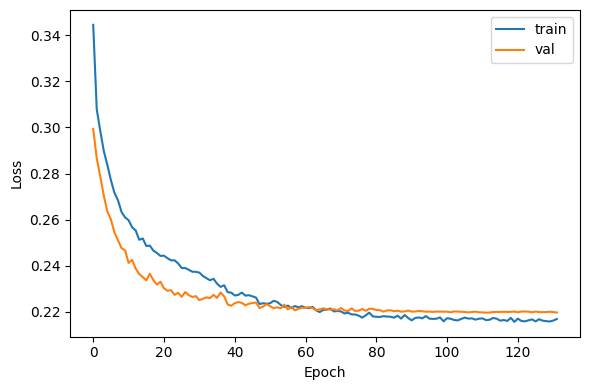

In [18]:
train_losses = [x["train_loss"] for x in history]
val_losses = [x["val_loss"] for x in history]

fig = plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

save_figure(fig, name_prefix="pca_unet_loss_curve")

plt.show()

# 3d加权窗函数

In [19]:
def build_blend_window_1d(length, min_weight=0.05):
    if length <= 1:
        return np.ones((length,), dtype=np.float32)

    w = np.hanning(length).astype(np.float32)
    w = min_weight + (1.0 - min_weight) * w
    w = np.clip(w, min_weight, None)
    return w


def build_blend_window_3d(f_len, h_len, w_len, min_weight=0.05):
    wf = build_blend_window_1d(f_len, min_weight=min_weight)[:, None, None]
    wh = build_blend_window_1d(h_len, min_weight=min_weight)[None, :, None]
    ww = build_blend_window_1d(w_len, min_weight=min_weight)[None, None, :]

    w3d = wf * wh * ww
    return w3d.astype(np.float32)

# PCA + UNet 的 weighted sliding inference

In [20]:
# 加权滑动窗口推理（测试阶段）
@torch.no_grad()
def predict_one_file_pca_unet_sliding(model, h5_path, stats, input_key="Observed_Patch", device="cuda"):
    """
    对单个 h5 文件进行完整立方体的 PCA+U-Net 推理。
    采用带权重的滑动窗口拼接，以消除边缘伪影。
    """
    model.eval()

    # 读原始数据
    x_raw = load_h5_array(h5_path, input_key)
    x_pca = pca_subtraction_cube(x_raw, n_comp=CFG.PCA_NCOMP, soft_f=CFG.PCA_SOFT_F)
    x_norm = normalize_array(x_pca, stats["input_mean"], stats["input_std"], clip_sigma=CFG.CLIP_SIGMA)

    Fdim, Hdim, Wdim = x_norm.shape
    pf, ph, pw = CFG.PATCH_F, CFG.PATCH_H, CFG.PATCH_W
    sf, sh, sw = CFG.INFER_STRIDE_F, CFG.INFER_STRIDE_H, CFG.INFER_STRIDE_W

    pred_sum = np.zeros((Fdim, Hdim, Wdim), dtype=np.float32)
    pred_cnt = np.zeros((Fdim, Hdim, Wdim), dtype=np.float32)

    # 构建三维权重窗口（汉宁窗）
    weight_window = build_blend_window_3d(pf, ph, pw, min_weight=CFG.BLEND_MIN_WEIGHT)

    # 生成滑动起点列表，确保覆盖边界
    f_starts = list(range(0, max(1, Fdim - pf + 1), sf))
    h_starts = list(range(0, max(1, Hdim - ph + 1), sh))
    w_starts = list(range(0, max(1, Wdim - pw + 1), sw))

    if len(f_starts) == 0 or f_starts[-1] != max(0, Fdim - pf):
        f_starts.append(max(0, Fdim - pf))
    if len(h_starts) == 0 or h_starts[-1] != max(0, Hdim - ph):
        h_starts.append(max(0, Hdim - ph))
    if len(w_starts) == 0 or w_starts[-1] != max(0, Wdim - pw):
        w_starts.append(max(0, Wdim - pw))

    f_starts = sorted(list(set(f_starts)))
    h_starts = sorted(list(set(h_starts)))
    w_starts = sorted(list(set(w_starts)))

    for f0 in f_starts:
        for h0 in h_starts:
            for w0 in w_starts:
                patch = x_norm[f0:f0+pf, h0:h0+ph, w0:w0+pw]
                patch_tensor = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(device)

                with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):
                    outputs = model(patch_tensor)

                if isinstance(outputs, list):
                    pred_patch = outputs[0].squeeze(0).squeeze(0).cpu().numpy()
                else:
                    pred_patch = outputs.squeeze(0).squeeze(0).cpu().numpy()

                pred_sum[f0:f0+pf, h0:h0+ph, w0:w0+pw] += pred_patch * weight_window
                pred_cnt[f0:f0+pf, h0:h0+ph, w0:w0+pw] += weight_window

    pred = pred_sum / np.maximum(pred_cnt, 1e-8)
    pred_denorm = denormalize_array(pred, stats["target_mean"], stats["target_std"])
    return pred_denorm, x_pca

# full-cube 测试指标

In [21]:
def compute_cube_metrics(pred, target):
    pred = np.asarray(pred, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)

    mse = np.mean((pred - target) ** 2)
    mae = np.mean(np.abs(pred - target))

    pred_center = pred - pred.mean()
    tgt_center = target - target.mean()
    corr = (pred_center * tgt_center).mean() / (pred_center.std() * tgt_center.std() + 1e-8)

    return {
        "mse": float(mse),
        "mae": float(mae),
        "corr": float(corr)
    }


@torch.no_grad()
def evaluate_checkpoint_fullcube(ckpt_path, model, test_files, stats, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_metrics = []

    for fp in test_files:
        pred_hi, _ = predict_one_file_pca_unet_sliding(
            model=model,
            h5_path=fp,
            stats=stats,
            input_key=CFG.INPUT_KEY,
            device=device
        )
        gt_hi = load_h5_array(fp, CFG.TARGET_KEY)
        all_metrics.append(compute_cube_metrics(pred_hi, gt_hi))

    mean_metrics = {
        "mse": float(np.mean([m["mse"] for m in all_metrics])),
        "mae": float(np.mean([m["mae"] for m in all_metrics])),
        "corr": float(np.mean([m["corr"] for m in all_metrics])),
    }

    print("\nCheckpoint:", ckpt_path)
    print("Saved epoch:", ckpt["epoch"])
    print("Full-cube test metrics:", mean_metrics)

    return mean_metrics


test_logs_loss = evaluate_checkpoint_fullcube(
    os.path.join(CFG.SAVE_DIR, CFG.BEST_BY_LOSS_NAME),
    model,
    test_files,
    stats,
    CFG.DEVICE
)

test_logs_corr = evaluate_checkpoint_fullcube(
    os.path.join(CFG.SAVE_DIR, CFG.BEST_BY_CORR_NAME),
    model,
    test_files,
    stats,
    CFG.DEVICE
)


Checkpoint: ./pca_unet_final/best_pca_unet_by_loss.pth
Saved epoch: 112
Full-cube test metrics: {'mse': 0.00013660330497545616, 'mae': 0.008973840488222412, 'corr': 0.6241560805650745}

Checkpoint: ./pca_unet_final/best_pca_unet_by_corr.pth
Saved epoch: 111
Full-cube test metrics: {'mse': 0.00013657312256290234, 'mae': 0.008980258262397652, 'corr': 0.6241807898607498}


# 单样本可视化

file: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/nonimaging_patch_cosine_outputs03/sim_mock474/NonImaging_Patch_cosine_surveysim-beam_474.h5
obs shape      : (250, 151, 49)
pca input shape: (250, 151, 49)
pred shape     : (250, 151, 49)
gt shape       : (250, 151, 49)
Saved PDF: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/unet成果图/pca_unet_compare_observed_pca_pred_gt_20260420_161405.pdf
Saved PNG: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/unet成果图/pca_unet_compare_observed_pca_pred_gt_20260420_161405.png


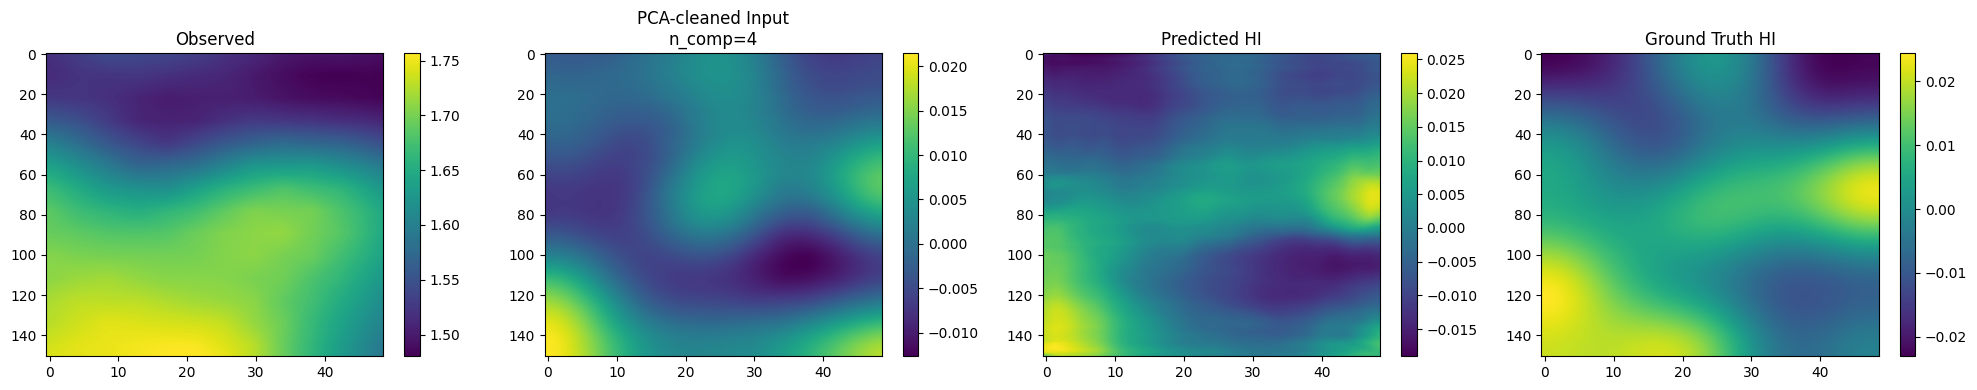

In [22]:
sample_test_file = test_files[0]

pred_hi, pca_input = predict_one_file_pca_unet_sliding(
    model=model,
    h5_path=sample_test_file,
    stats=stats,
    input_key=CFG.INPUT_KEY,
    device=CFG.DEVICE
)

gt_hi = load_h5_array(sample_test_file, CFG.TARGET_KEY)
obs = load_h5_array(sample_test_file, CFG.INPUT_KEY)

print("file:", sample_test_file)
print("obs shape      :", obs.shape)
print("pca input shape:", pca_input.shape)
print("pred shape     :", pred_hi.shape)
print("gt shape       :", gt_hi.shape)

freq_idx = obs.shape[0] // 2

fig = plt.figure(figsize=(20, 4))

plt.subplot(1, 4, 1)
plt.imshow(obs[freq_idx], aspect="auto", interpolation=CFG.DISPLAY_INTERP)
plt.title("Observed")
plt.colorbar()

plt.subplot(1, 4, 2)
plt.imshow(pca_input[freq_idx], aspect="auto", interpolation=CFG.DISPLAY_INTERP)
plt.title(f"PCA-cleaned Input\nn_comp={CFG.PCA_NCOMP}")
plt.colorbar()

plt.subplot(1, 4, 3)
plt.imshow(pred_hi[freq_idx], aspect="auto", interpolation=CFG.DISPLAY_INTERP)
plt.title("Predicted HI")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.imshow(gt_hi[freq_idx], aspect="auto", interpolation=CFG.DISPLAY_INTERP)
plt.title("Ground Truth HI")
plt.colorbar()

plt.tight_layout()

save_figure(fig, name_prefix="pca_unet_compare_observed_pca_pred_gt")

plt.show()

# 误差对比

In [23]:
before_mse = np.mean((pca_input - gt_hi) ** 2)
after_mse = np.mean((pred_hi - gt_hi) ** 2)

before_mae = np.mean(np.abs(pca_input - gt_hi))
after_mae = np.mean(np.abs(pred_hi - gt_hi))

print(f"PCA input -> GT   MSE: {before_mse:.6f}")
print(f"UNet pred -> GT   MSE: {after_mse:.6f}")
print(f"PCA input -> GT   MAE: {before_mae:.6f}")
print(f"UNet pred -> GT   MAE: {after_mae:.6f}")
print(f"MSE improvement: {(before_mse - after_mse)/(before_mse + 1e-12)*100:.2f}%")
print(f"MAE improvement: {(before_mae - after_mae)/(before_mae + 1e-12)*100:.2f}%")

PCA input -> GT   MSE: 0.000195
UNet pred -> GT   MSE: 0.000160
PCA input -> GT   MAE: 0.010372
UNet pred -> GT   MAE: 0.009504
MSE improvement: 17.61%
MAE improvement: 8.37%


# 残差可视化

Saved PDF: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/unet成果图/pca_unet_residual_compare_20260420_161412.pdf
Saved PNG: /home/liuyucheng/hi/mearkat/new/SWGSimulator-master1/unet成果图/pca_unet_residual_compare_20260420_161412.png


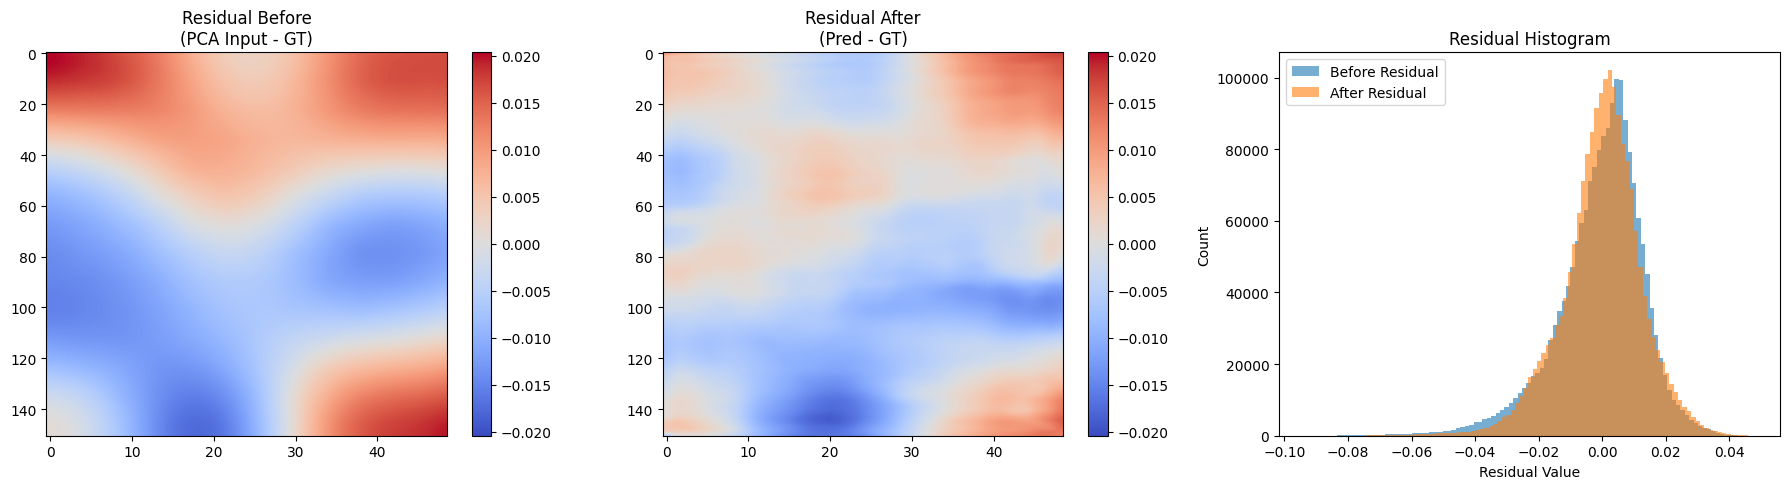

Before residual RMS: 0.013940
After  residual RMS: 0.012666
GT RMS            : 0.015493
Residual reduction: 9.14%


In [24]:
res_before = pca_input - gt_hi
res_after = pred_hi - gt_hi

freq_idx = gt_hi.shape[0] // 2

vmax_res = max(
    np.max(np.abs(res_before[freq_idx])),
    np.max(np.abs(res_after[freq_idx]))
)

fig = plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(
    res_before[freq_idx],
    aspect="auto",
    cmap="coolwarm",
    vmin=-vmax_res,
    vmax=vmax_res,
    interpolation=CFG.DISPLAY_INTERP
)
plt.title("Residual Before\n(PCA Input - GT)")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(
    res_after[freq_idx],
    aspect="auto",
    cmap="coolwarm",
    vmin=-vmax_res,
    vmax=vmax_res,
    interpolation=CFG.DISPLAY_INTERP
)
plt.title("Residual After\n(Pred - GT)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.hist(res_before.ravel(), bins=100, alpha=0.6, label="Before Residual")
plt.hist(res_after.ravel(), bins=100, alpha=0.6, label="After Residual")
plt.title("Residual Histogram")
plt.xlabel("Residual Value")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()

save_figure(fig, name_prefix="pca_unet_residual_compare")

plt.show()

print(f"Before residual RMS: {np.std(res_before):.6f}")
print(f"After  residual RMS: {np.std(res_after):.6f}")
print(f"GT RMS            : {np.std(gt_hi):.6f}")
print(f"Residual reduction: {(np.std(res_before) - np.std(res_after)) / (np.std(res_before) + 1e-12) * 100:.2f}%")